# Impact of Colors and Magnitude Cuts on the reddshift distribution

## Import packages

We start by importing the Python packages we'll use throughout this notebook.

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import fitsio

# Make plots look nicer
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 13

## Load the CMASS catalog

In [16]:
#cmass_filename = '/fs/ess/PHS0411/summer/cmass-dr12v4-S-Reid-full.dat.fits'
cmass_filename = '/fs/ess/PHS0411/summer/galaxy_DR12v5_CMASS_South.fits.gz'
cmass = fitsio.read(cmass_filename)

# Subsample to 50,000 galaxies for faster plotting
rng  = np.random.default_rng(42)
idx  = rng.choice(len(cmass), size=50000, replace=False)
cmass = cmass[idx]

## Obtain Magnitudes and Colors from Flux

In [ ]:
# CMASS magnitudes 

data = cmass 
flux       = data['MODELFLUX']      # shape (N, 5) — u,g,r,i,z
extinction = data['EXTINCTION']     # shape (N, 5) — u,g,r,i,z

# Convert flux to magnitude
# Clip flux at a small positive value to avoid log(0) errors
flux_clipped = np.clip(flux, 1e-6, None)
mag = 22.5 - 2.5 * np.log10(flux_clipped)

# Apply extinction correction
mag_corrected = mag - extinction

# Extract individual bands for convenience
cmass_mag_u = mag_corrected[:, 0]
cmass_mag_g = mag_corrected[:, 1]
cmass_mag_r = mag_corrected[:, 2]
cmass_mag_i = mag_corrected[:, 3]
cmass_mag_z = mag_corrected[:, 4]

print('CMASS Magnitude statistics (extinction-corrected):')
for name, m in zip(['u','g','r','i','z'], [cmass_mag_u, cmass_mag_g, cmass_mag_r, cmass_mag_i, cmass_mag_z]):
    print(f'  {name}-band:  mean = {np.mean(m):.2f},  std = {np.std(m):.2f}')

CMASS Magnitude statistics (extinction-corrected):
  u-band:  mean = 28.18,  std = 6.78
  g-band:  mean = 22.01,  std = 0.67
  r-band:  mean = 20.39,  std = 0.50
  i-band:  mean = 19.41,  std = 0.41
  z-band:  mean = 18.99,  std = 0.58


In [ ]:
# Compute CMASS colors
cmass_color_gr = cmass_mag_g - cmass_mag_r
cmass_color_ri = cmass_mag_r - cmass_mag_i
cmass_color_iz = cmass_mag_i - cmass_mag_z

print('CMASS Color statistics:')
for name, c in zip(['g-r', 'r-i', 'i-z'], [cmass_color_gr, cmass_color_ri, cmass_color_iz]):
    mask = np.isfinite(c)
    print(f'  {name}:  mean = {np.mean(c[mask]):.3f},  std = {np.std(c[mask]):.3f}')

CMASS Color statistics:
  g-r:  mean = 1.622,  std = 0.410
  r-i:  mean = 0.977,  std = 0.167
  i-z:  mean = 0.421,  std = 0.398


# Divide CMASS into two subsamples based on $i$ band magnitude

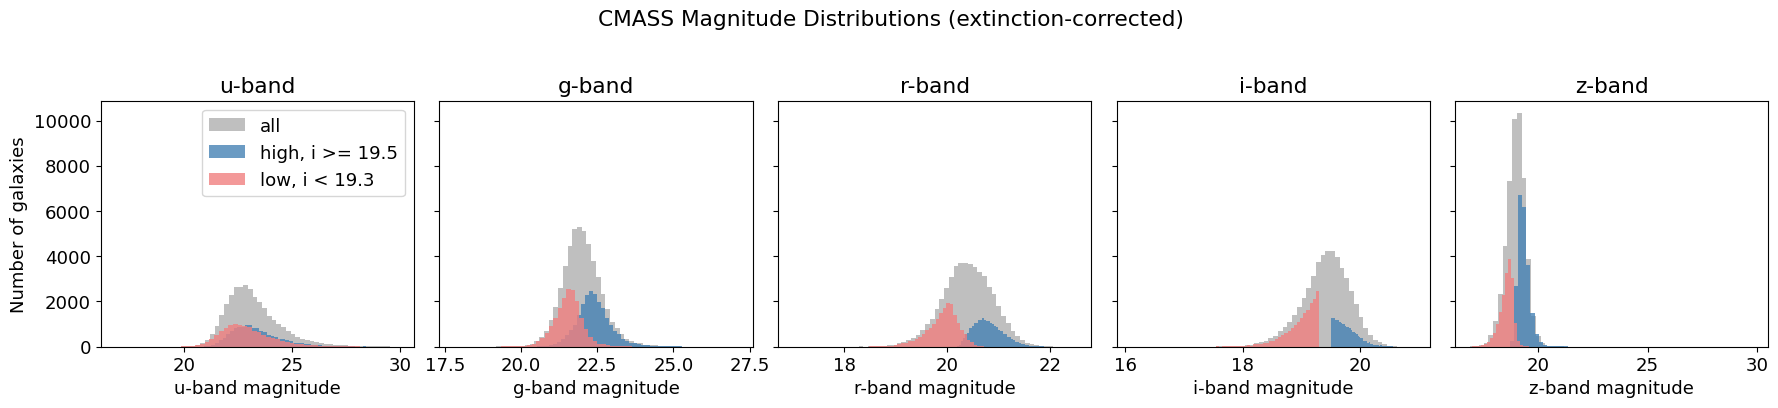

In [79]:
bands  = ['u', 'g', 'r', 'i', 'z']
mags   = [cmass_mag_u, cmass_mag_g, cmass_mag_r, cmass_mag_i, cmass_mag_z]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)


# Define masks for low and high i-band magnitude
mask_low_i = (cmass_mag_i < 19.3) 
mask_high_i = (cmass_mag_i >= 19.5) 


for ax, band, m in zip(axes, bands, mags):
    # Only plot galaxies with reasonable magnitudes
    mask = (m > 10) & (m < 30)
    
    ax.hist(m[mask], bins=60, alpha=0.5, color='gray', edgecolor='none', label='all')
    # Apply high i-band magnitude 
    ax.hist(m[mask_high_i & mask], bins=60, alpha=0.8, color='steelblue', edgecolor='none', label='high, i >= 19.5')

    # Apply low i-band magnitude
    ax.hist(m[mask_low_i & mask], bins=60, alpha=0.8, color='lightcoral', edgecolor='none', label='low, i < 19.3')
    ax.set_xlabel(f'{band}-band magnitude')
    ax.set_title(f'{band}-band')

axes[0].legend()
axes[0].set_ylabel('Number of galaxies')
fig.suptitle('CMASS Magnitude Distributions (extinction-corrected)', y=1.02)

plt.tight_layout()
plt.show()

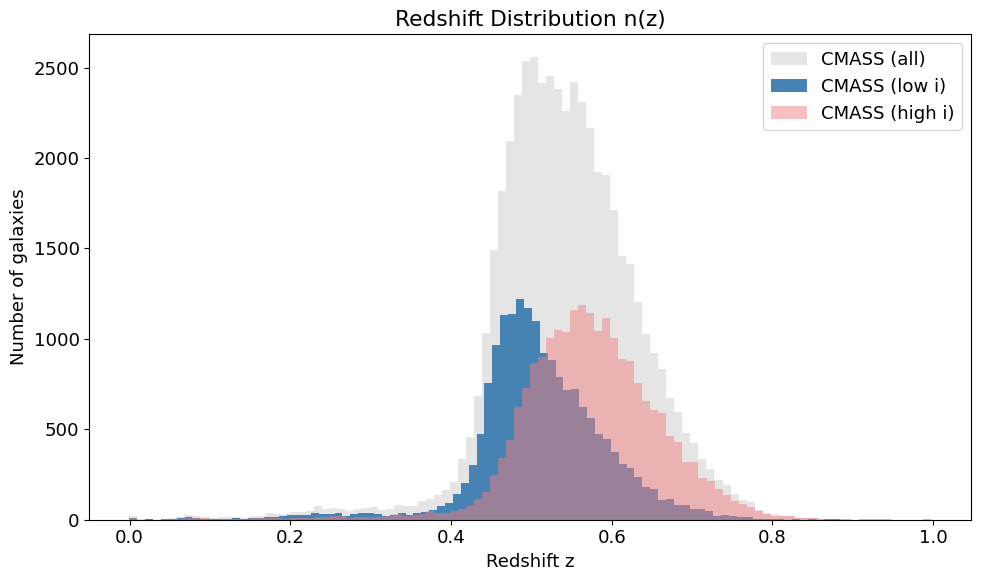

Median redshift: 0.540


In [80]:
fig, ax = plt.subplots()

ax.hist(cmass['Z'], bins=100, color='gray', edgecolor='none', alpha=0.2,  label='CMASS (all)')
ax.hist(cmass['Z'][mask_low_i], bins=100, color='steelblue', edgecolor='none', label='CMASS (low i)')
ax.hist(cmass['Z'][mask_high_i], bins=100, color='lightcoral', alpha=0.5, edgecolor='none', label='CMASS (high i)')

ax.set_xlabel('Redshift z')
ax.set_ylabel('Number of galaxies')
ax.set_title('Redshift Distribution n(z)')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Median redshift: {np.median(cmass["Z"]):.3f}')

# Divide CMASS into two subsamples based on r-i color

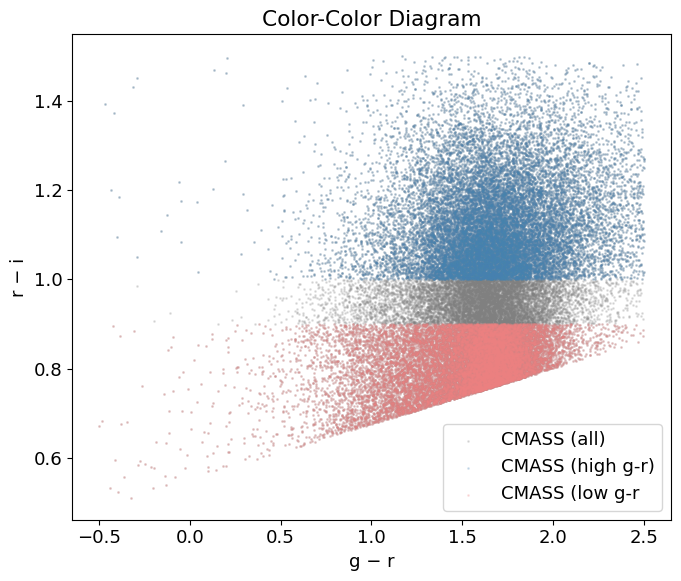

In [81]:
# Mask out unreasonable values
cmass_mask = (cmass_color_gr > -0.5) & (cmass_color_gr < 2.5) & (cmass_color_ri > -0.5) & (cmass_color_ri < 1.5)

cmass_1_mask = (cmass_color_ri > 1.0) & cmass_mask
cmass_2_mask = (cmass_color_ri < 0.9) & cmass_mask

fig, ax = plt.subplots(figsize=(7, 6))

#ax.scatter(combine_gr[combine_mask], combine_ri[combine_mask], s=1, alpha=0.1, color='gray', rasterized=True)
ax.scatter(cmass_color_gr[cmass_mask], cmass_color_ri[cmass_mask], s=1, alpha=0.2, color='gray', rasterized=True, label='CMASS (all)')
ax.scatter(cmass_color_gr[cmass_1_mask], cmass_color_ri[cmass_1_mask], s=1, alpha=0.2, color='steelblue', rasterized=True, label='CMASS (high g-r)')
ax.scatter(cmass_color_gr[cmass_2_mask], cmass_color_ri[cmass_2_mask], s=1, alpha=0.2, color='lightcoral', rasterized=True, label='CMASS (low g-r')



ax.set_xlabel('g − r')
ax.set_ylabel('r − i')
ax.set_title('Color-Color Diagram')
ax.legend()


plt.tight_layout()
plt.show()

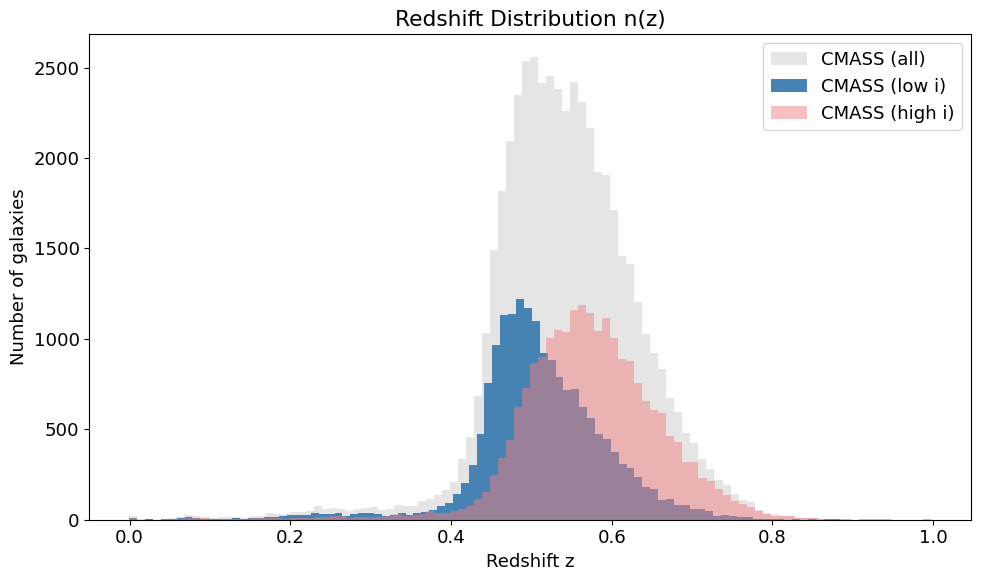

Median redshift: 0.540


In [82]:
fig, ax = plt.subplots()

ax.hist(cmass['Z'], bins=100, color='gray', edgecolor='none', alpha=0.2,  label='CMASS (all)')
ax.hist(cmass['Z'][mask_low_i], bins=100, color='steelblue', edgecolor='none', label='CMASS (low i)')
ax.hist(cmass['Z'][mask_high_i], bins=100, color='lightcoral', alpha=0.5, edgecolor='none', label='CMASS (high i)')

ax.set_xlabel('Redshift z')
ax.set_ylabel('Number of galaxies')
ax.set_title('Redshift Distribution n(z)')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Median redshift: {np.median(cmass["Z"]):.3f}')

# Divide CMASS into two subsamples based on g-r color

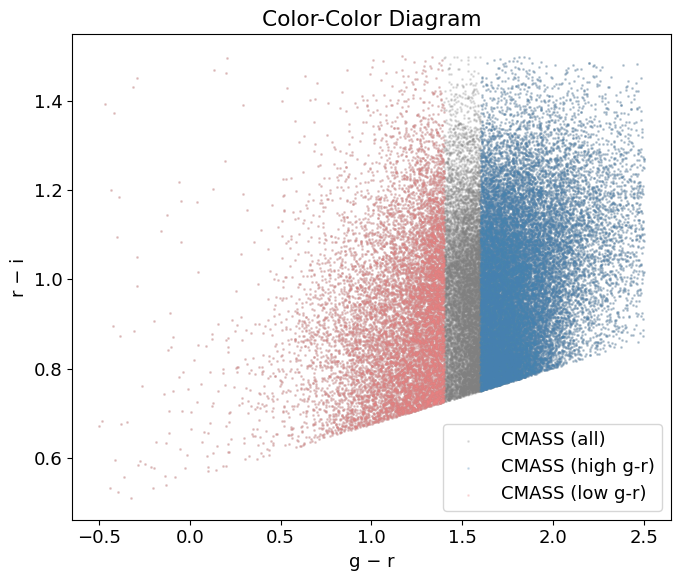

In [83]:
# Mask out unreasonable values
cmass_mask = (cmass_color_gr > -0.5) & (cmass_color_gr < 2.5) & (cmass_color_ri > -0.5) & (cmass_color_ri < 1.5)

cmass_1_mask = (cmass_color_gr > 1.6) & cmass_mask
cmass_2_mask = (cmass_color_gr < 1.4) & cmass_mask

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(cmass_color_gr[cmass_mask], cmass_color_ri[cmass_mask], s=1, alpha=0.2, color='gray', rasterized=True, label='CMASS (all)')
ax.scatter(cmass_color_gr[cmass_1_mask], cmass_color_ri[cmass_1_mask], s=1, alpha=0.2, color='steelblue', rasterized=True, label='CMASS (high g-r)')
ax.scatter(cmass_color_gr[cmass_2_mask], cmass_color_ri[cmass_2_mask], s=1, alpha=0.2, color='lightcoral', rasterized=True, label='CMASS (low g-r)')



ax.set_xlabel('g − r')
ax.set_ylabel('r − i')
ax.set_title('Color-Color Diagram')
ax.legend()


plt.tight_layout()
plt.show()

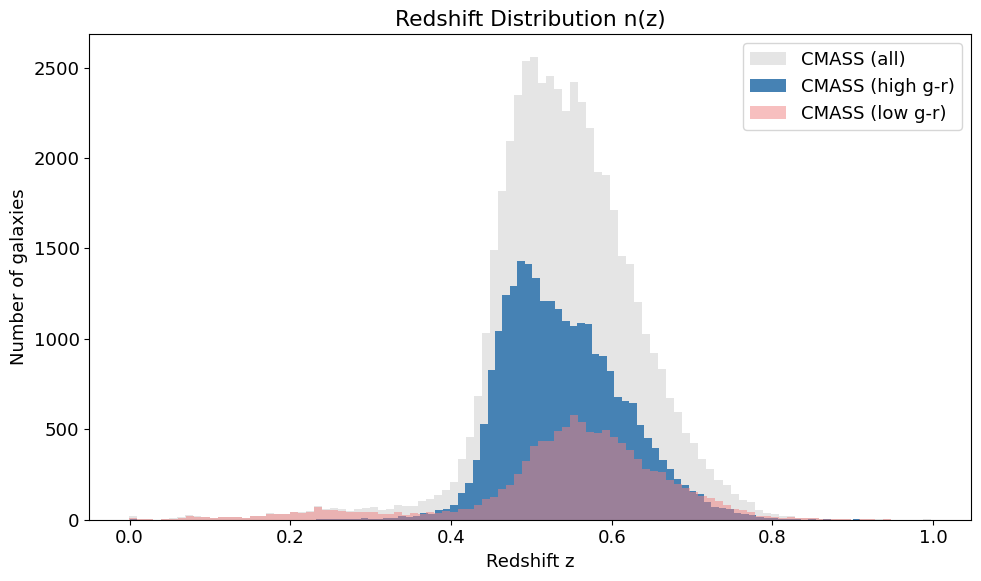

Median redshift: 0.540


In [84]:
fig, ax = plt.subplots()

ax.hist(cmass['Z'], bins=100, color='gray', edgecolor='none', alpha=0.2,  label='CMASS (all)')
ax.hist(cmass['Z'][cmass_1_mask], bins=100, color='steelblue', edgecolor='none', label='CMASS (high g-r)')
ax.hist(cmass['Z'][cmass_2_mask], bins=100, color='lightcoral', alpha=0.5, edgecolor='none', label='CMASS (low g-r)')

ax.set_xlabel('Redshift z')
ax.set_ylabel('Number of galaxies')
ax.set_title('Redshift Distribution n(z)')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Median redshift: {np.median(cmass["Z"]):.3f}')